<a href="https://colab.research.google.com/github/Lijan-Baral/GitHub-CST184/blob/main/Week10_Tutorial_Sugar_and_Obesity_r.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Scenario:

You are part of a global health task force investigating whether dietary sugar intake is associated with higher obesity rates across countries. Using data from 25 nations, you’ll conduct a hypothesis test, build a regression model, and visualize your findings.

Real-world focus: SDG 3 – Good Health and Well-Being

**Step 0 – Load the Data**

In [ ]:
data <- read.csv("/content/sdg3_sugar_obesity_data.csv")
head(data) #This shows the first five data of the dataset

,Country,Sugar_Intake_g_per_day,Obesity_Rate_percent
,<chr>,<dbl>,<dbl>
1,Australia,81.3,28.5
2,Brazil,85.7,31.0
3,Canada,42.3,22.7
4,China,53.7,21.5
5,France,94.8,37.5
6,Germany,106.7,37.8


Step 1 – Explore the Data

      Country   Sugar_Intake_g_per_day Obesity_Rate_percent
 Length   :25   Min.   : 42.30         Min.   :12.40       
 N.unique :25   1st Qu.: 55.00         1st Qu.:20.60       
 N.blank  : 0   Median : 81.30         Median :24.90       
 Min.nchar: 5   Mean   : 76.03         Mean   :28.04       
 Max.nchar:14   3rd Qu.: 94.80         3rd Qu.:37.00       
                Max.   :117.20         Max.   :45.30       

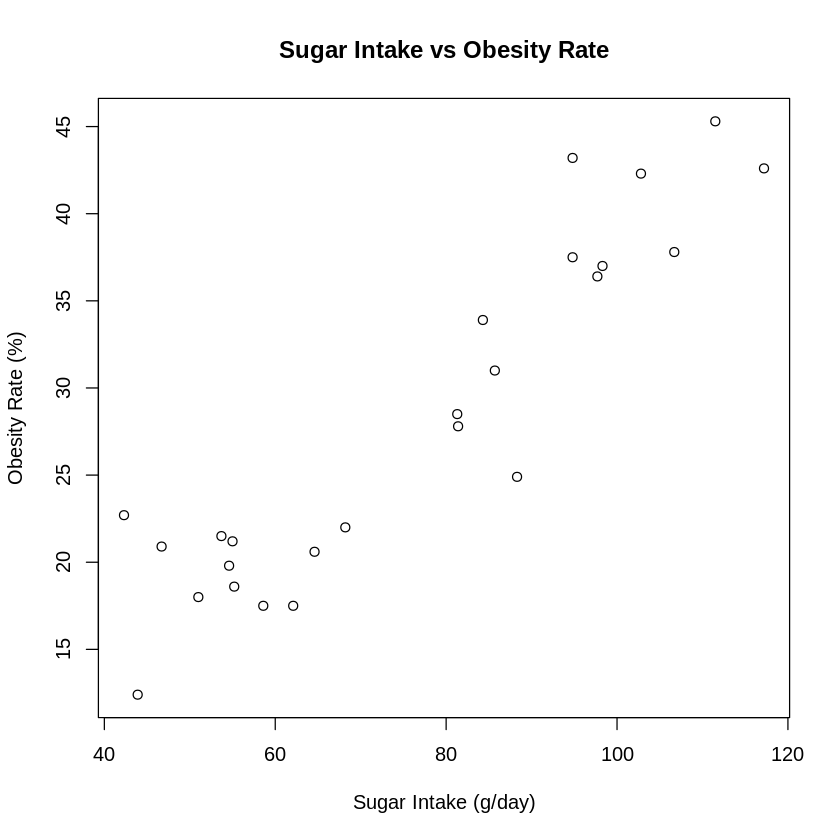

In [ ]:
summary(data) #To show the stastistic data of the dataset.
plot(data$Sugar_Intake_g_per_day, data$Obesity_Rate_percent,
     main = "Sugar Intake vs Obesity Rate",
     xlab = "Sugar Intake (g/day)",
     ylab = "Obesity Rate (%)")

Prompt: Change the axis labels or title and observe the output.

Ans:

main: Updates the title at the very top of the plot.

xlab: Changes the horizontal axis label at the bottom.

ylab: Changes the vertical axis label on the left side.

Step 2 – Hypothesis Test


In [ ]:
# Create groups
avg_sugar <- mean(data$Sugar_Intake_g_per_day)
data$Group <- ifelse(data$Sugar_Intake_g_per_day > avg_sugar, "High", "Low")

# Run t-test
t.test(Obesity_Rate_percent ~ Group, data = data)


	Welch Two Sample t-test

data:  Obesity_Rate_percent by Group
t = 8.4184, df = 16.684, p-value = 2.084e-07
alternative hypothesis: true difference in means between group High and group Low is not equal to 0
95 percent confidence interval:
 12.45148 20.79595
sample estimates:
mean in group High  mean in group Low 
          36.01538           19.39167 


Interpret:

Here, we conducted t-test which shows the two groups have very different obesity rates.The 95% confidence interval (12.45% to 20.80%) indicates that the true difference in average obesity rates between the two groups is likely to fall within this range. Countries in the  high group have an average obesity rate of about 36%, while those in the Low group average only 19%. Because the p-value (2.084 × 10⁻⁷) is much smaller than 0.05, the difference is considered highly significant. This concludes that belonging to the High group is associated with a much higher obesity rate.

Prompt: Try replacing "High" with "Above Avg" and see what happens to the grouping.



In [ ]:
# Create groups
avg_sugar <- mean(data$Sugar_Intake_g_per_day)
data$Group <- ifelse(data$Sugar_Intake_g_per_day > avg_sugar, "Above Avg", "Low")

# Run t-test
t.test(Obesity_Rate_percent ~ Group, data = data)


	Welch Two Sample t-test

data:  Obesity_Rate_percent by Group
t = 8.4184, df = 16.684, p-value = 2.084e-07
alternative hypothesis: true difference in means between group Above Avg and group Low is not equal to 0
95 percent confidence interval:
 12.45148 20.79595
sample estimates:
mean in group Above Avg       mean in group Low 
               36.01538                19.39167 


Interpret: There is no change in high and above average group according to data as they are similar.

Step 3 – Build the Regression Model

In [ ]:
model <- lm(Obesity_Rate_percent ~ Sugar_Intake_g_per_day, data = data)
summary(model)


Call:
lm(formula = Obesity_Rate_percent ~ Sugar_Intake_g_per_day, data = data)

Residuals:
    Min      1Q  Median      3Q     Max 
-7.9611 -2.3481 -0.1956  2.2429  7.9251 

Coefficients:
                       Estimate Std. Error t value Pr(>|t|)    
(Intercept)            -1.85648    2.66618  -0.696    0.493    
Sugar_Intake_g_per_day  0.39318    0.03361  11.699 3.66e-11 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 3.807 on 23 degrees of freedom
Multiple R-squared:  0.8561,	Adjusted R-squared:  0.8499 
F-statistic: 136.9 on 1 and 23 DF,  p-value: 3.664e-11


Interpret:

The analysis shows that countries with higher daily sugar intake tend to have higher obesity rates. On average, every additional 1 gram of sugar consumed per day is linked to about a 0.39% increase in the obesity rate. Also, he p-value is extremely small, the relationship suggest a strong association between sugar consumption and obesity.Next,the model has r^2 of 0.86 i.e approximately 85.6% of the variation in obesity rates can be explained by differences in daily sugar intake.

Step 4 – Visualize the Model

`geom_smooth()` using formula = 'y ~ x'


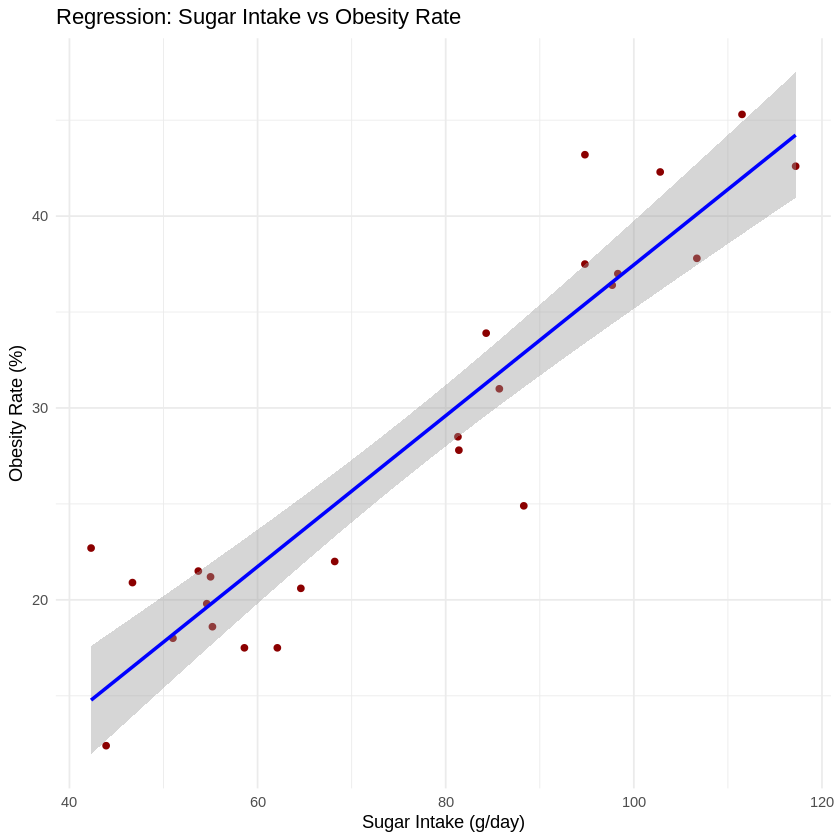

In [ ]:
library(ggplot2)

ggplot(data, aes(x = Sugar_Intake_g_per_day, y = Obesity_Rate_percent)) +
  geom_point(color = "darkred") +
  geom_smooth(method = "lm", se = TRUE, color = "blue") +
  labs(
    title = "Regression: Sugar Intake vs Obesity Rate",
    x = "Sugar Intake (g/day)",
    y = "Obesity Rate (%)"
  ) +
  theme_minimal()

Interpret:

The scatter plot shows the relationship between daily sugar intake (g/day) and obesity rate (%). The blue regression line slopes upward, indicating a positive linear relationship between the two variables. Next is Most of the data points are clustered close to the regression line, suggesting that the model fits the data well.The grey shaded area represents the 95% confidence interval showing the range within which the true regression line is likely to lie.

Overall pattern suggests that higher sugar intake is strongly associated with higher obesity levels in this dataset.

Prompt: Change the color of the points or the title to reflect your interpretation of the results.

`geom_smooth()` using formula = 'y ~ x'


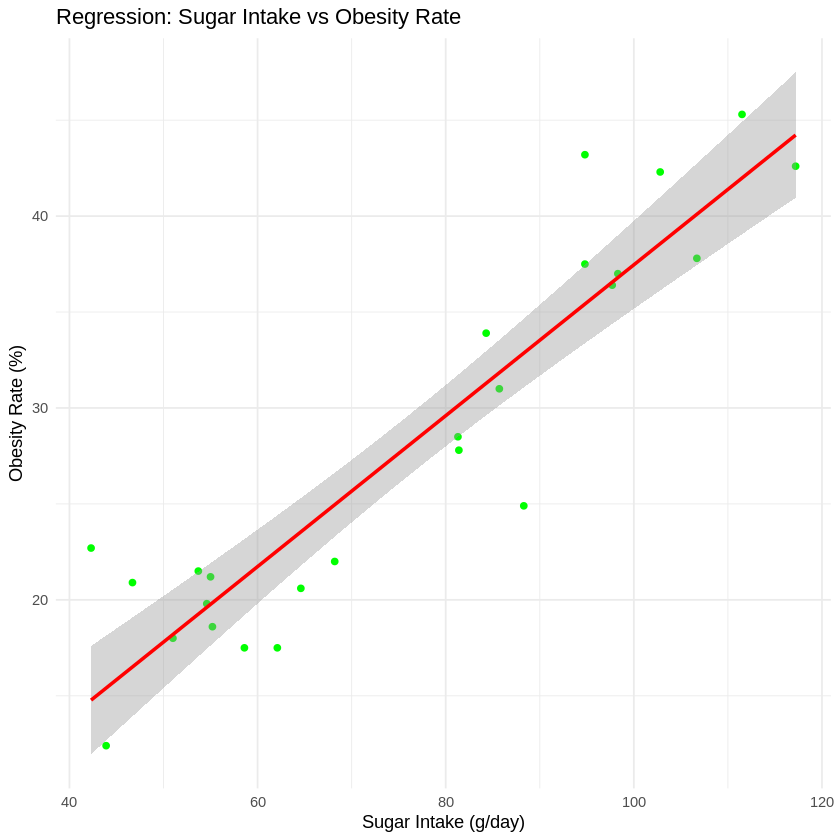

In [ ]:
ggplot(data, aes(x = Sugar_Intake_g_per_day, y = Obesity_Rate_percent)) +
  geom_point(color = "green") +
  geom_smooth(method = "lm", se = TRUE, color = "red") +
  labs(
    title = "Regression: Sugar Intake vs Obesity Rate",
    x = "Sugar Intake (g/day)",
    y = "Obesity Rate (%)"
  ) +
  theme_minimal()

Step 5 – Try These Variations

In [ ]:
# What happens if you remove one outlier (e.g., the country with the highest sugar intake)?

# 1. Identify the outlier (highest sugar intake)
max_sugar <- max(data$Sugar_Intake_g_per_day)

# 2. Filter out the outlier
data_no_outlier <- subset(data, Sugar_Intake_g_per_day < max_sugar)

# 3. Fit a new regression model without the outlier
model_no_outlier <- lm(Obesity_Rate_percent ~ Sugar_Intake_g_per_day, data = data_no_outlier)

# 4. View summary of the new model
summary(model_no_outlier)


Call:
lm(formula = Obesity_Rate_percent ~ Sugar_Intake_g_per_day, data = data_no_outlier)

Residuals:
    Min      1Q  Median      3Q     Max 
-8.1168 -2.6454 -0.2441  2.3490  8.0589 

Coefficients:
                       Estimate Std. Error t value Pr(>|t|)    
(Intercept)            -2.25657    2.84864  -0.792    0.437    
Sugar_Intake_g_per_day  0.39947    0.03683  10.847 2.69e-10 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 3.874 on 22 degrees of freedom
Multiple R-squared:  0.8425,	Adjusted R-squared:  0.8353 
F-statistic: 117.7 on 1 and 22 DF,  p-value: 2.694e-10


Answer: $R^2$ decreases slightly,Slope remains nearly identical,relationship remains strongly statistically significant ($p = 2.69 \times 10^{-10} \ll 0.001$) i.e p < 0.05.

In conclusion, The outlier does not Completely affect the regression line; the strong positive association between sugar intake and obesity rate is almost same across the entire dataset.

In [ ]:
# How does increasing sugar variability affect R²?

# 1. Store original R-squared (from model)
r2_original <- summary(model)$r.squared
cat("Original R-squared:", round(r2_original, 4), "\n")

# 2. Add random noise to Sugar_Intake_g_per_day to increase its variability
set.seed(42) # For reproducible results
data$Sugar_High_Var <- data$Sugar_Intake_g_per_day + rnorm(nrow(data), mean = 0, sd = 25)

# 3. Fit new model with higher variability predictor
model_high_var <- lm(Obesity_Rate_percent ~ Sugar_High_Var, data = data)

# 4. Display high variability R-squared
r2_high_var <- summary(model_high_var)$r.squared
cat("High Variability R-squared:", round(r2_high_var, 4), "\n")

Original R-squared: 0.8561 
High Variability R-squared: 0.1847 


Answer: Increasing the variability (noise) in the predictor variable decreases $R^2$.

Extra: Try using ggsave("my_plot.png") to export your chart!

In [ ]:
ggsave("my_plot.png")

Saving 6.67 x 6.67 in image
`geom_smooth()` using formula = 'y ~ x'
